In [1]:
import os
import random
import shutil

# Always start from current folder
BASE_PATH = "."

ANNOTATED_PATH = os.path.join(BASE_PATH, "Annnotated")
IMAGES_PATH = os.path.join(ANNOTATED_PATH, "images")
LABELS_PATH = os.path.join(ANNOTATED_PATH, "labels")

# Output dataset folder
OUTPUT_PATH = os.path.join(BASE_PATH, "data")

TRAIN_IMG = os.path.join(OUTPUT_PATH, "images/train")
VAL_IMG = os.path.join(OUTPUT_PATH, "images/val")
TRAIN_LBL = os.path.join(OUTPUT_PATH, "labels/train")
VAL_LBL = os.path.join(OUTPUT_PATH, "labels/val")

# Create folders
for path in [TRAIN_IMG, VAL_IMG, TRAIN_LBL, VAL_LBL]:
    os.makedirs(path, exist_ok=True)

print("✅ Paths ready")

✅ Paths ready


In [2]:
print("Current folder:", os.listdir("."))
print("Annotated folder:", os.listdir(ANNOTATED_PATH))
print("Images exist?", os.path.exists(IMAGES_PATH))
print("Labels exist?", os.path.exists(LABELS_PATH))

Current folder: ['Annnotated', 'College_SAM2 (1).ipynb', 'College_SAM2_update2.ipynb', 'College_SAM2_update2.zip', 'data', 'requirements.txt', 'runs', 'venv', 'yolo26n.pt', 'yolov8n.pt', 'yolov8s.pt']
Annotated folder: ['classes.txt', 'images', 'labels', 'notes.json']
Images exist? True
Labels exist? True


In [3]:
# Fix randomness
random.seed(42)

# Get images
images = [f for f in os.listdir(IMAGES_PATH) if f.endswith((".jpg", ".png", ".jpeg"))]

print("Total images:", len(images))

# Shuffle
random.shuffle(images)

# Split 80/20
split_idx = int(0.8 * len(images))
train_files = images[:split_idx]
val_files = images[split_idx:]

print(f"Train: {len(train_files)}")
print(f"Val: {len(val_files)}")

Total images: 278
Train: 222
Val: 56


In [4]:
yaml_content = f"""
path: {OUTPUT_PATH}

train: images/train
val: images/val

names:
  0: bacterial_blight
  1: brown_spot
  2: leaf_blast
  3: tungro
"""

yaml_path = os.path.join(OUTPUT_PATH, "dataset.yaml")

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created")

✅ dataset.yaml created


In [5]:
print(os.listdir("."))
print(os.listdir("Annnotated"))

['Annnotated', 'College_SAM2 (1).ipynb', 'College_SAM2_update2.ipynb', 'College_SAM2_update2.zip', 'data', 'requirements.txt', 'runs', 'venv', 'yolo26n.pt', 'yolov8n.pt', 'yolov8s.pt']
['classes.txt', 'images', 'labels', 'notes.json']


In [6]:
from ultralytics import YOLO

In [7]:
model = YOLO("yolov8n.pt")

In [8]:
# import torch
# print(torch.version.cuda)          # should show 12.9
# print(torch.cuda.is_available())   # should be True
# print(torch.cuda.get_device_name(0))


In [9]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
Device Count: 1
GPU: NVIDIA GeForce RTX 2050


In [10]:
import shutil

def move_files(file_list, img_dest, lbl_dest):
    for file in file_list:
        shutil.copy(f"Annnotated/images/{file}", f"{img_dest}/{file}")

        label_file = file.rsplit(".", 1)[0] + ".txt"
        src_lbl = f"Annnotated/labels/{label_file}"
        dst_lbl = f"{lbl_dest}/{label_file}"

        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)
        else:
            open(dst_lbl, 'w').close()

move_files(train_files, "data/images/train", "data/labels/train")
move_files(val_files, "data/images/val", "data/labels/val")

print("Files moved again!")

Files moved again!


In [11]:
model.train(
    data="data/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.39  Python-3.12.4 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3

KeyboardInterrupt: 

In [ ]:
model = YOLO("runs/detect/train-2/weights/best.pt")
model(r"data\Blast\BLAST1_053.JPG", show=True)


image 1/1 c:\Users\Aman\OneDrive\Documents\Coding\SAM_College\data\Blast\BLAST1_053.JPG: 640x640 2 tungros, 113.4ms
Speed: 14.2ms preprocess, 113.4ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bacterial_blight', 1: 'brown_spot', 2: 'leaf_blast', 3: 'tungro'}
 obb: None
 orig_img: array([[[ 28,  67,  41],
         [ 30,  69,  43],
         [ 31,  70,  44],
         ...,
         [237, 216, 218],
         [237, 216, 218],
         [236, 215, 217]],
 
        [[ 27,  66,  40],
         [ 28,  67,  41],
         [ 30,  69,  43],
         ...,
         [237, 219, 220],
         [239, 218, 220],
         [236, 218, 219]],
 
        [[ 26,  65,  39],
         [ 28,  67,  41],
         [ 29,  68,  42],
         ...,
         [234, 218, 219],
         [235, 217, 218],
         [233, 217, 218]],
 
        ...,
 
        [[ 53,  94,  57],
         [ 53,  94,  57],
         [ 53,  94,  57],
         ...,
         [  9,  37,  17],
         [ 10,  38,  18],
         [ 11,  39,  19]],
 
        [[ 54,  95,  58],
         [ 54,  95,  58],
 

USING yolov8s.pt

In [12]:
YOLO("yolov8s.pt")

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="data/dataset.yaml",
    epochs=100,
    imgsz=512,     # reduced
    batch=4,       # reduce if needed
    device=0,
    cache=False,   # IMPORTANT
    name="rice_disease_v2"
)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.39  Python-3.12.4 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rice_d

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000258C91452B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          


model(r"data\Blast\BLAST1_053.JPG", show=True)

In [15]:

model(r"data\Blast\BLAST1_053.JPG", show=True)

WARNING Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


image 1/1 c:\Users\Aman\OneDrive\Documents\Coding\SAM_College\data\Blast\BLAST1_053.JPG: 512x512 2 bacterial_blights, 1 tungro, 14.3ms
Speed: 2.8ms preprocess, 14.3ms inference, 3.8ms postprocess per image at shape (1, 3, 512, 512)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bacterial_blight', 1: 'brown_spot', 2: 'leaf_blast', 3: 'tungro'}
 obb: None
 orig_img: array([[[ 28,  67,  41],
         [ 30,  69,  43],
         [ 31,  70,  44],
         ...,
         [237, 216, 218],
         [237, 216, 218],
         [236, 215, 217]],
 
        [[ 27,  66,  40],
         [ 28,  67,  41],
         [ 30,  69,  43],
         ...,
         [237, 219, 220],
         [239, 218, 220],
         [236, 218, 219]],
 
        [[ 26,  65,  39],
         [ 28,  67,  41],
         [ 29,  68,  42],
         ...,
         [234, 218, 219],
         [235, 217, 218],
         [233, 217, 218]],
 
        ...,
 
        [[ 53,  94,  57],
         [ 53,  94,  57],
         [ 53,  94,  57],
         ...,
         [  9,  37,  17],
         [ 10,  38,  18],
         [ 11,  39,  19]],
 
        [[ 54,  95,  58],
         [ 54,  95,  58],
 

In [14]:
# from ultralytics import YOLO

# model = YOLO("yolov8s.pt")

# model.train(
#     data="data/dataset.yaml",
#     epochs=100,
#     imgsz=512,     # reduced
#     batch=4,       # reduce if needed
#     device=0,
#     cache=False,   # IMPORTANT
#     name="rice_disease_v2"
# )

In [16]:
# pip install segment-anything

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import urllib.request

# url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
# output_path = "sam_vit_b.pth"

# urllib.request.urlretrieve(url, output_path)

# print("Downloaded SAM model!")

Downloaded SAM model!


In [9]:
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load YOLO
yolo_model = YOLO("runs/detect/rice_disease_v2-3/weights/best.pt")

# Load SAM
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda")
predictor = SamPredictor(sam)

In [11]:
image_path = "BROWNSPOT1_017.jpg"

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image_rgb)

In [12]:
results = yolo_model(image_path)

boxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()


image 1/1 c:\Users\Aman\OneDrive\Documents\Coding\SAM_College\BROWNSPOT1_017.jpg: 512x512 7 brown_spots, 15.5ms
Speed: 1.9ms preprocess, 15.5ms inference, 3.3ms postprocess per image at shape (1, 3, 512, 512)


In [13]:
for box in boxes:
    x1, y1, x2, y2 = box.astype(int)

    input_box = np.array([x1, y1, x2, y2])

    masks, scores, logits = predictor.predict(
    box=input_box,
    multimask_output=True
    )

    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]

    # remove small noisy regions
    best_mask = best_mask.astype(np.uint8)

In [14]:
import cv2

kernel = np.ones((5,5), np.uint8)

best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_CLOSE, kernel)
best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_OPEN, kernel)

In [25]:
x1, y1, x2, y2 = box.astype(int)

pad = 20  # reduce box slightly
x1 += pad
y1 += pad
x2 -= pad
y2 -= pad

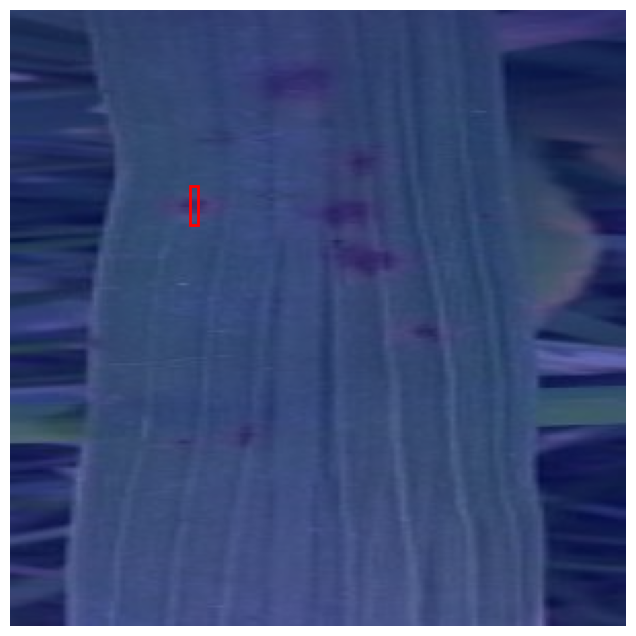

In [26]:
plt.figure(figsize=(8,8))

plt.imshow(image_rgb)

if best_mask is not None:
    plt.imshow(best_mask, alpha=0.5, cmap='jet')

plt.gca().add_patch(
    plt.Rectangle((x1, y1), x2-x1, y2-y1,
                  edgecolor='red', fill=False, linewidth=2)
)

plt.axis('off')
plt.show()

In [27]:
disease_pixels = best_mask.sum()
total_pixels = best_mask.shape[0] * best_mask.shape[1]

severity = (disease_pixels / total_pixels) * 100
print(f"Severity: {severity:.2f}%")

Severity: 0.00%


In [28]:
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [29]:
# Load YOLO model
yolo_model = YOLO("runs/detect/rice_disease_v2-3/weights/best.pt")

# Load SAM model
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda")
predictor = SamPredictor(sam)

print("Models loaded ✅")

Models loaded ✅


In [30]:
image_path = "BROWNSPOT1_017.jpg"   # change this

image = cv2.imread(image_path)

if image is None:
    print("Image not found ❌")
else:
    print("Image loaded ✅")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image_rgb)

Image loaded ✅


In [31]:
results = yolo_model(image_path, conf=0.25)

boxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

print("Detected boxes:", len(boxes))


image 1/1 c:\Users\Aman\OneDrive\Documents\Coding\SAM_College\BROWNSPOT1_017.jpg: 512x512 7 brown_spots, 13.4ms
Speed: 1.4ms preprocess, 13.4ms inference, 2.1ms postprocess per image at shape (1, 3, 512, 512)
Detected boxes: 7


In [32]:
final_masks = []

for box in boxes:
    x1, y1, x2, y2 = box.astype(int)

    # 🔥 shrink box slightly (improves SAM)
    pad = 10
    x1 = max(0, x1 + pad)
    y1 = max(0, y1 + pad)
    x2 = max(0, x2 - pad)
    y2 = max(0, y2 - pad)

    input_box = np.array([x1, y1, x2, y2])

    masks, scores, _ = predictor.predict(
        box=input_box,
        multimask_output=True
    )

    # best mask
    best_mask = masks[np.argmax(scores)]

    # 🔥 convert to uint8
    best_mask = best_mask.astype(np.uint8)

    # 🔥 smooth mask
    kernel = np.ones((5,5), np.uint8)
    best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_CLOSE, kernel)
    best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_OPEN, kernel)

    final_masks.append((best_mask, (x1, y1, x2, y2)))

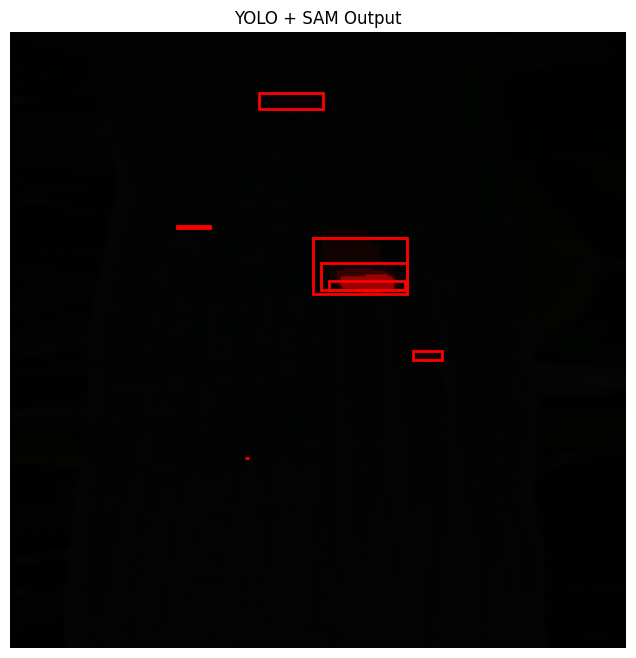

In [33]:
plt.figure(figsize=(8,8))
plt.imshow(image_rgb)

for mask, (x1, y1, x2, y2) in final_masks:

    # create colored mask
    colored_mask = np.zeros_like(image_rgb)
    colored_mask[:,:,0] = mask * 255   # red

    plt.imshow(colored_mask, alpha=0.4)

    # draw bounding box
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      edgecolor='red', fill=False, linewidth=2)
    )

plt.axis('off')
plt.title("YOLO + SAM Output")
plt.show()

Models loaded ✅

image 1/1 c:\Users\Aman\OneDrive\Documents\Coding\SAM_College\BROWNSPOT1_017.jpg: 512x512 3 brown_spots, 14.9ms
Speed: 3.3ms preprocess, 14.9ms inference, 3.1ms postprocess per image at shape (1, 3, 512, 512)
Using best box only ✅


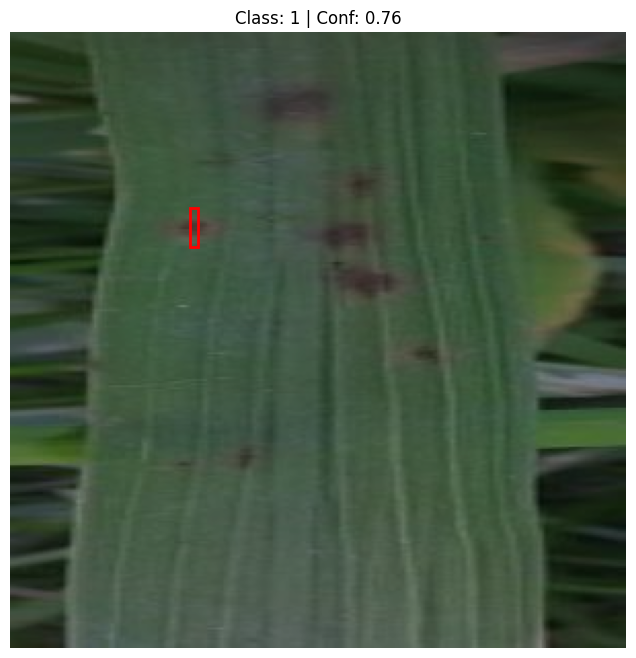

Severity: 0.00%


In [34]:
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor


import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


model = YOLO(r"runs\detect\rice_disease_v2-3\weights\best.pt")
# YOLO model (your trained model)
yolo_model = YOLO("runs/detect/rice_disease_v2-3/weights/best.pt")

# SAM model
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda")
predictor = SamPredictor(sam)

print("Models loaded ✅")

image_path = "BROWNSPOT1_017.jpg"

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image_rgb)

results = yolo_model(image_path, conf=0.5)

# get boxes + scores
boxes = results[0].boxes.xyxy.cpu().numpy()
scores = results[0].boxes.conf.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

if len(boxes) == 0:
    print("No detection ❌")
    exit()

# 🔥 pick ONLY best box
best_idx = np.argmax(scores)

box = boxes[best_idx]
cls = classes[best_idx]
score = scores[best_idx]

print("Using best box only ✅")

x1, y1, x2, y2 = box.astype(int)

# shrink box slightly (important)
pad = 20
x1 = max(0, x1 + pad)
y1 = max(0, y1 + pad)
x2 = max(0, x2 - pad)
y2 = max(0, y2 - pad)

input_box = np.array([x1, y1, x2, y2])


masks, scores_sam, _ = predictor.predict(
    box=input_box,
    multimask_output=True
)

# best SAM mask
best_mask = masks[np.argmax(scores_sam)]
best_mask = best_mask.astype(np.uint8)
best_mask = (best_mask > 0.5).astype(np.uint8)

kernel = np.ones((5,5), np.uint8)

best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_CLOSE, kernel)
best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)

# colored mask
colored_mask = np.zeros_like(image_rgb)
colored_mask[:,:,0] = best_mask * 255

plt.imshow(colored_mask, alpha=0.4)

# draw ONE box
plt.gca().add_patch(
    plt.Rectangle((x1, y1), x2-x1, y2-y1,
                  edgecolor='red', fill=False, linewidth=2)
)

plt.title(f"Class: {int(cls)} | Conf: {score:.2f}")
plt.axis('off')
plt.show()

disease_pixels = np.sum(best_mask)
total_pixels = best_mask.shape[0] * best_mask.shape[1]

severity = (disease_pixels / total_pixels) * 100

print(f"Severity: {severity:.2f}%")
